# Проект: Прогнозирование стоимости недвижимости

## Этап 1. Исследование данных (EDA)

### 1.1 Знакомство с данными

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('real_estate_data.csv')
df.shape

(403487, 17)

В датасете 403 487 строк и 17 столбцов.

In [3]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [4]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [5]:
# случайная строка для проверки
df.sample(1, random_state=1)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
253215,253216,Konut,Daire,10/23/18,11/8/18,1,16,0,10-20 arası,6,2+1,NaN,Adana/Seyhan/2000 Evler,NaN,Kombi (Doğalgaz),183000.0,TRY


Датасет содержит объявления о продаже и аренде недвижимости с турецкого сервиса Zingat. Это площадка-посредник между покупателями/арендаторами и продавцами/арендодателями недвижимости.

Описание признаков:
- id — номер объявления;
- type — тип недвижимости (в датасете только одно значение — Konut, т.е. жильё);
- sub_type — подтип жилья (Daire — квартира, Villa — вилла и т.д.);
- start_date / end_date — даты публикации и снятия объявления;
- listing_type — тип объявления: 1 — продажа, 2 — аренда, 3 — прочее;
- tom — сколько дней объявление находилось на рынке (time on market);
- building_age — возраст здания;
- total_floor_count — этажность дома;
- floor_no — этаж, на котором расположена квартира;
- room_count — количество комнат (например, 2+1 — 2 комнаты + гостиная);
- size — площадь в м²;
- address — адрес в формате город/район/квартал;
- furnished — меблировка;
- heating_type — тип отопления;
- price — цена (целевая переменная);
- price_currency — валюта цены.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

Всего 3 числовых столбца (float64), 3 столбца int64 и 11 столбцов типа object. По df.info() сразу видно, что часть столбцов (end_date, building_age, size, furnished и др.) содержат пропуски.

### 1.2 Описательная статистика

In [7]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


По числовым столбцам:
- listing_type — медиана 1, то есть среди объявлений преобладает продажа (1), аренда (2) встречается реже;
- tom — объявление в среднем находится на рынке 57 дней, максимум ограничен 180 днями;
- size — здесь явно есть выбросы: медиана 110 м², а максимум почти 950 000 м², так быть не может;
- furnished — count = 0, то есть столбец полностью пустой, толку от него не будет;
- price — та же история, что и с площадью: медиана ≈ 199 000, а максимум — 2 млрд, огромные выбросы.

In [8]:
df.describe(include='object')

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,44,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,60914,157363,5611,204150,400677


По категориальным столбцам:
- type — всего 1 уникальное значение (Konut), для модели это бесполезный признак;
- sub_type — 12 категорий, чаще всего встречается Daire (квартира);
- room_count — больше всего вариантов 3+1;
- address — очень много уникальных адресов (это, по сути, город/район/квартал одной строкой), напрямую в модель такой признак не пойдёт, нужно будет разбивать.

In [9]:
print('Асимметрия (skew) цены:', df['price'].skew())

Асимметрия (skew) цены: 308.50702657456833


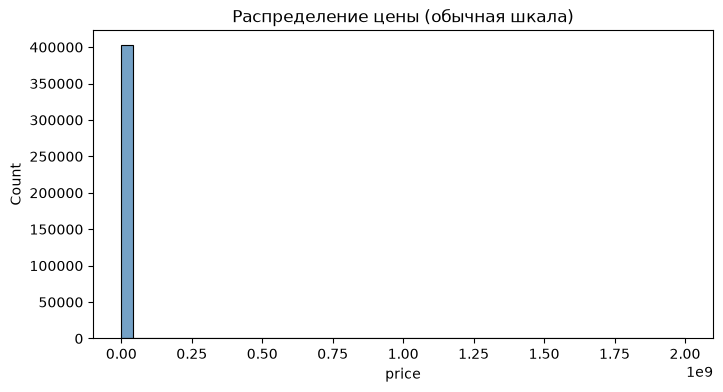

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df.loc[df['price'] > 0, 'price'], bins=50, color='steelblue')
plt.title('Распределение цены (обычная шкала)')
plt.show()

Асимметрия цены огромная (больше 300!), и на гистограмме в обычной шкале это отлично видно: почти все столбики прижаты к нулю, а редкие огромные выбросы растягивают ось так, что основное распределение не разглядеть. Перед моделированием цену, скорее всего, нужно будет логарифмировать — в логарифмической шкале распределение выглядит гораздо адекватнее (см. следующий пункт).

### 1.3 Визуальный анализ

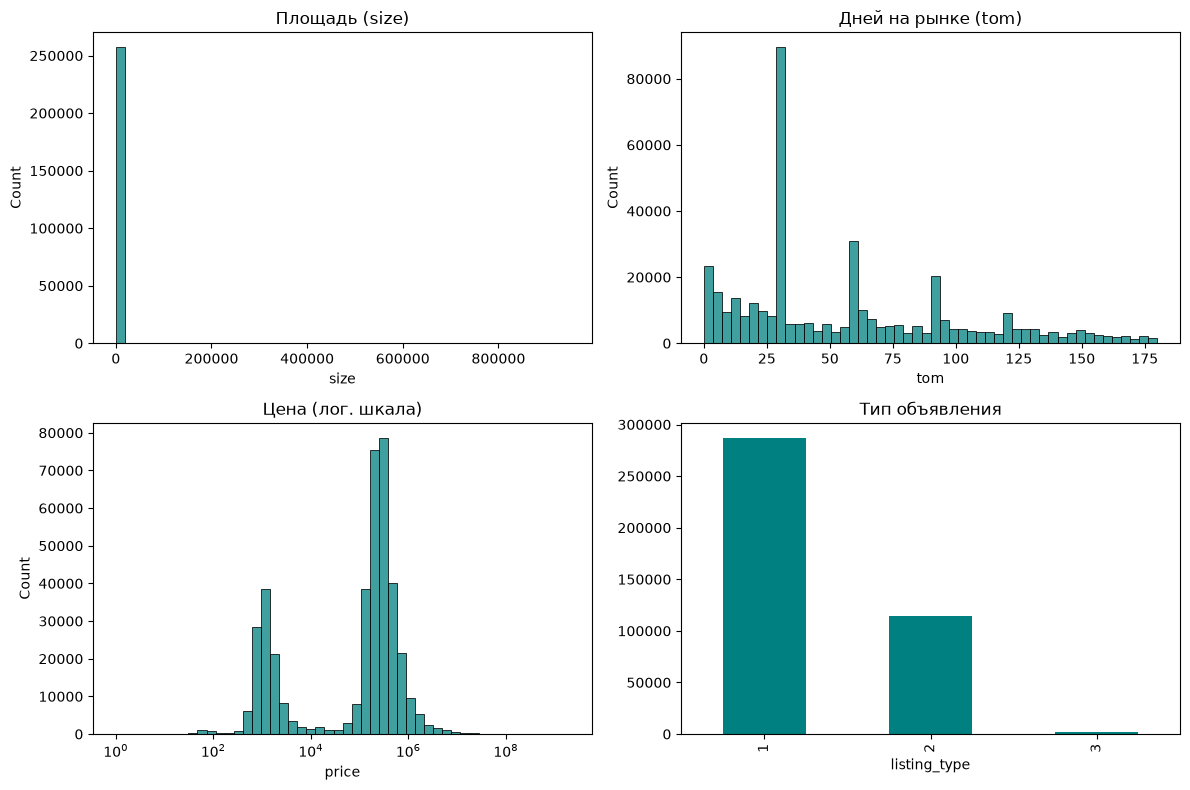

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['size'].dropna(), bins=50, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Площадь (size)')

sns.histplot(df['tom'], bins=50, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Дней на рынке (tom)')

sns.histplot(df.loc[df['price'] > 0, 'price'], bins=50, log_scale=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Цена (лог. шкала)')

df['listing_type'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Тип объявления')

plt.tight_layout()
plt.show()

- size — гистограмма сжата в одну точку слева из-за редких аномально больших значений;
- tom — резкие пики на 30, 60, 90, 120, 180 днях, похоже, что площадка сама снимает объявления по этим срокам;
- price в логарифмической шкале — видно два «горба»: слева это аренда (цены поменьше), справа — продажа;
- listing_type — продажа (1) встречается гораздо чаще аренды (2), тип 3 почти не встречается.

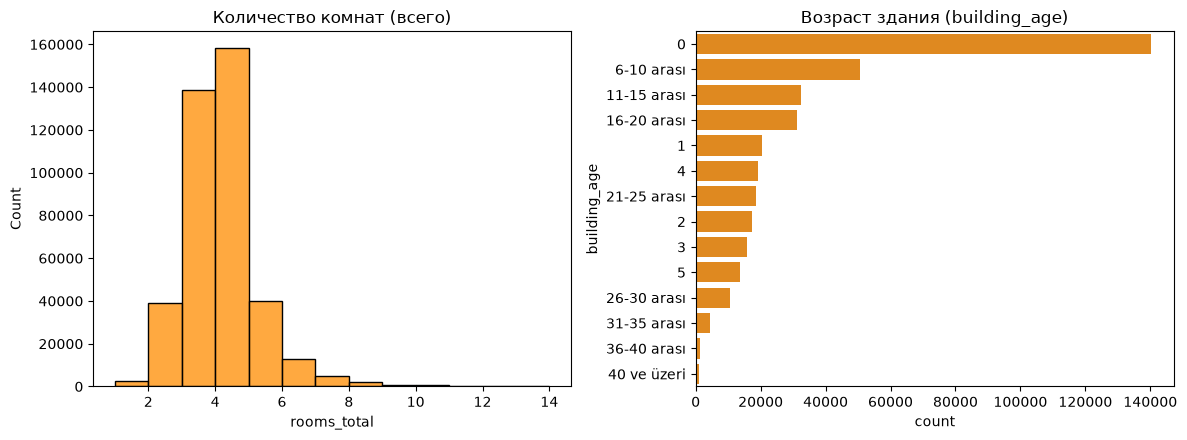

In [12]:
import re

# room_count хранится как текст вида "2+1", достаю из него общее число комнат
def parse_rooms(value):
    if pd.isna(value):
        return np.nan
    nums = re.findall(r'\d+', str(value))
    if len(nums) == 2:
        return int(nums[0]) + int(nums[1])
    return np.nan

df['rooms_total'] = df['room_count'].apply(parse_rooms)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['rooms_total'].dropna(), bins=range(1, 15), ax=axes[0], color='darkorange')
axes[0].set_title('Количество комнат (всего)')

age_order = df['building_age'].value_counts().index
sns.countplot(data=df, y='building_age', order=age_order, ax=axes[1], color='darkorange')
axes[1].set_title('Возраст здания (building_age)')

plt.tight_layout()
plt.show()

Чаще всего встречаются квартиры с 3-4 комнатами всего (то есть 2+1 и 3+1). По возрасту здания больше всего новостроек ('0' — только что построенные), дальше идут дома возрастом 6-10 лет.

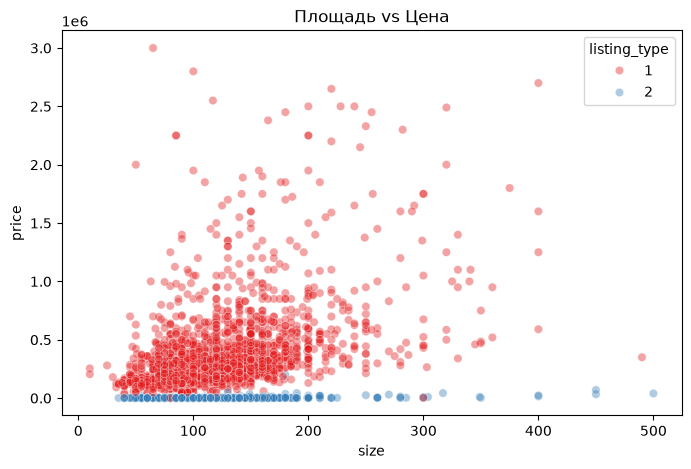

In [13]:
sample = df[df['size'].between(10, 500) & df['price'].between(1000, 3_000_000)].sample(3000, random_state=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='size', y='price', hue='listing_type', alpha=0.4, palette='Set1')
plt.title('Площадь vs Цена')
plt.show()

Чем больше площадь, тем выше цена — зависимость видна, хотя разброс большой. Также хорошо видно, что точки аренды (listing_type=2) лежат заметно ниже точек продажи (listing_type=1) — это две разные ценовые категории.

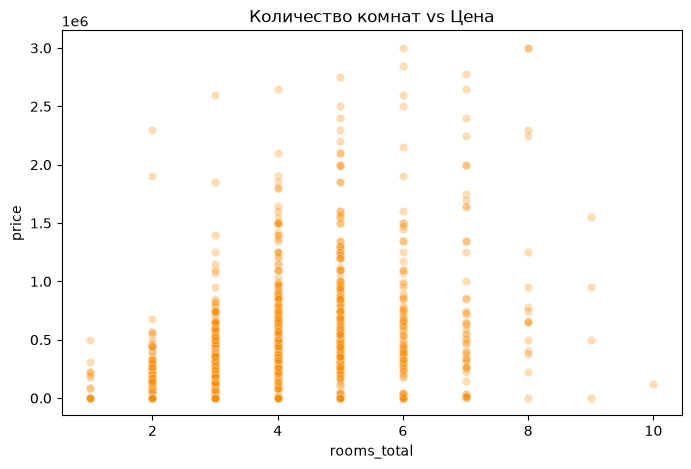

In [14]:
sample2 = df[df['price'].between(1000, 3_000_000) & df['rooms_total'].between(1, 10)].sample(3000, random_state=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample2, x='rooms_total', y='price', alpha=0.3, color='darkorange')
plt.title('Количество комнат vs Цена')
plt.show()

Цена тоже растёт вместе с количеством комнат, но тут разброс ещё больше, чем у площади — скорее всего потому что количество комнат само по себе грубее площади (например, 3+1 может быть и 70 м², и 130 м²).

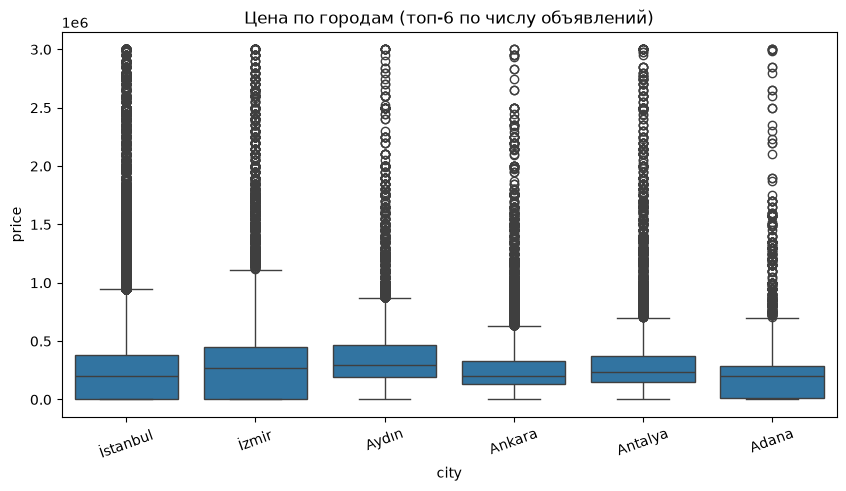

In [15]:
df['city'] = df['address'].str.split('/').str[0]
top_cities = df['city'].value_counts().head(6).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df['city'].isin(top_cities) & df['price'].between(1000, 3_000_000)],
    x='city', y='price'
)
plt.xticks(rotation=20)
plt.title('Цена по городам (топ-6 по числу объявлений)')
plt.show()

Из адреса выделила город (первая часть строки до /). В топ-6 городов по числу объявлений median-цена сильно различается: например, в Айдыне и Измире цены выше, чем в Стамбуле и Анкаре, хотя объявлений в Стамбуле больше всего. Значит, город/район — важный признак.

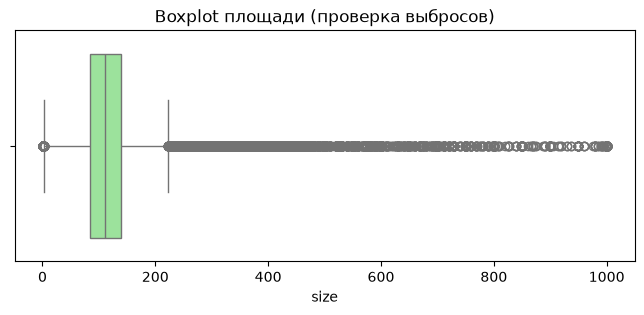

In [16]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df[df['size'].between(1, 1000)]['size'], color='lightgreen')
plt.title('Boxplot площади (проверка выбросов)')
plt.show()

Даже если сразу ограничить площадь до 1000 м² (а в датасете есть значения и в сотни тысяч м²!), boxplot всё равно показывает огромное количество точек-выбросов справа. Это ещё раз подтверждает, что на этапе предобработки площадь нужно будет чистить от аномалий.

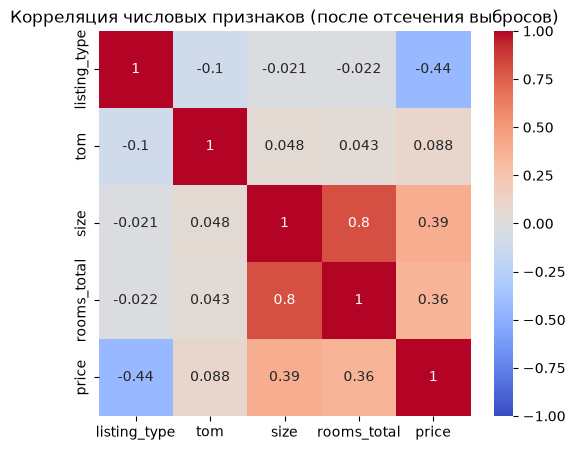

In [17]:
num_cols = ['listing_type', 'tom', 'size', 'rooms_total', 'price']
filtered = df[df['size'].between(10, 500) & df['price'].between(1000, 3_000_000)]

plt.figure(figsize=(6, 5))
sns.heatmap(filtered[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция числовых признаков (после отсечения выбросов)')
plt.show()

Сначала я считала корреляцию на «сырых» данных, но из-за огромных выбросов в price и size она получалась почти нулевой и бессмысленной. После отсечения явных аномалий (площадь 10–500 м², цена 1000–3 000 000) картина стала понятнее:
- listing_type и price — заметная отрицательная связь (-0.44): у аренды (2) цена меньше, чем у продажи (1);
- size и price — положительная связь (+0.39): больше площадь — выше цена;
- rooms_total и price — тоже положительная связь (+0.36), похожая на площадь, что логично — это связанные признаки;
- tom почти не связан с ценой.

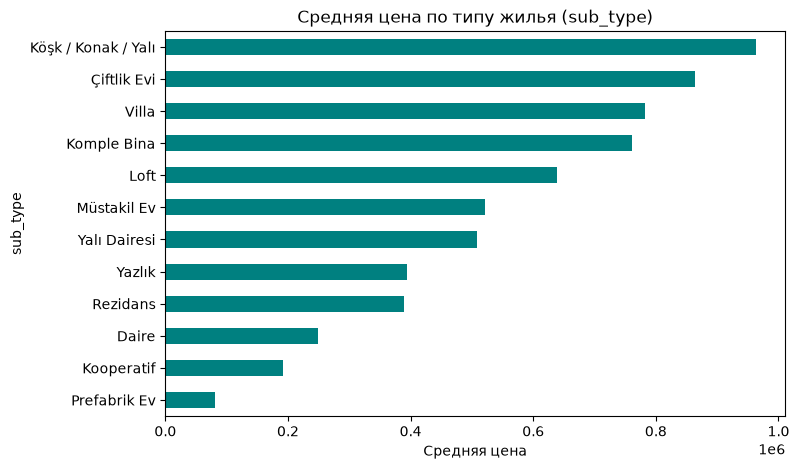

In [18]:
mean_price = filtered.groupby('sub_type')['price'].mean().sort_values()

plt.figure(figsize=(8, 5))
mean_price.plot(kind='barh', color='teal')
plt.title('Средняя цена по типу жилья (sub_type)')
plt.xlabel('Средняя цена')
plt.show()

Самые дешёвые в среднем — сборные дома (Prefabrik Ev), самые дорогие — особняки/усадьбы (Köşk/Konak/Yalı) и виллы. Обычная квартира (Daire, самая частая категория) по цене где-то в середине списка.

### 1.4 Анализ пропусков и аномалий

In [19]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'пропусков': missing, 'процент, %': missing_pct}).sort_values('процент, %', ascending=False)

,пропусков,"процент, %"
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
rooms_total,2898,0.72
price_currency,715,0.18
price,715,0.18


Больше всего пропусков в furnished — 100%, столбец совсем без данных, на следующем этапе его логично удалить. Дальше по количеству пропусков: end_date (34%), size (36%), floor_no (9%), total_floor_count и heating_type (7%), building_age (7%). У price/price_currency пропусков мало (715 строк).

In [20]:
df.duplicated().sum()

np.int64(0)

Полных дубликатов строк нет.

In [21]:
df['id'].duplicated().sum()

np.int64(0)

По id тоже дубликатов нет, id — уникальный ключ.

In [22]:
print('Цены <= 0:', (df['price'] <= 0).sum())
print('Площадь <= 0:', (df['size'] <= 0).sum())
df['price_currency'].value_counts(dropna=False)

Цены <= 0: 45
Площадь <= 0: 0


price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64

Есть 44 объявления с ценой 0 и 1 с ценой отрицательной — это явные ошибки ввода, такие строки нужно будет убрать. Отрицательных/нулевых значений площади нет. Валюта в основном TRY, но встречаются USD, EUR, GBP (и 715 пропусков) — цены в разных валютах напрямую сравнивать нельзя, нужно будет привести к одной.

In [23]:
df['building_age'].value_counts()

building_age
0              140174
6-10 arası      50495
11-15 arası     32309
16-20 arası     31333
1               20355
4               19032
21-25 arası     18438
2               17466
3               15651
5               13589
26-30 arası     10581
31-35 arası      4268
36-40 arası      1347
40 ve üzeri      1059
Name: count, dtype: int64

Значения building_age выглядят адекватно: '0' — новостройка, остальные — диапазоны лет ('6-10 arası' и т.п.), проверила на нереалистичные значения (отрицательный возраст, дом старше 100 лет и т.п.) — таких не нашлось.

In [24]:
# при разборе room_count в отдельные числа комнат (см. 1.3) часть строк не распозналась
print('Не удалось распознать формат room_count:', df['rooms_total'].isna().sum())
df.loc[df['rooms_total'].isna(), 'room_count'].value_counts()

Не удалось распознать формат room_count: 2898


room_count
+    2898
Name: count, dtype: int64

Нашла ещё одну аномалию: у 2898 объявлений room_count равен просто '+' без единой цифры — явно битые данные, из текста никак не понять, сколько там комнат. На этапе предобработки такие строки, скорее всего, придётся удалить или заполнить самой частой категорией.

### 1.5 Промежуточные выводы

По итогам первого этапа можно сформулировать несколько гипотез, которые проверю на следующих этапах:

1. Тип объявления (продажа/аренда) сильнее всего влияет на цену — на боксплоте и в корреляции разница между продажей и арендой хорошо видна.
2. Площадь (size) положительно влияет на цену — подтверждается диаграммой рассеяния и корреляцией (+0.39 после очистки от выбросов).
3. Город/район важен для цены — медианная цена по топ-городам заметно различается.
4. Тип жилья (sub_type) тоже влияет на цену — виллы и особняки в среднем в несколько раз дороже квартир и сборных домов.
5. Без очистки от выбросов и пропусков модель работать не будет — в price и size огромные выбросы (вплоть до 2 млрд и почти 1 млн м²), а furnished придётся удалить полностью из-за 100% пропусков.

## Этап 2. Предварительная обработка данных

На первом этапе (EDA) я изучила сырые данные и нашла много проблем: сильный разброс цен, пропуски, опечатки и выбросы. Чтобы подготовить датасет к машинному обучению, на этом этапе я выполню:
- Очистку от дубликатов, приведение цен к одной валюте (TRY) и фильтрацию объявлений;
- Корректное заполнение пропусков в комнатах, этажах, возрасте здания и площади;
- Устранение аномалий и выбросов, логарифмирование целевой переменной для стабилизации дисперсии;
- Feature Engineering: создание новых признаков и удаление признаков с утечкой таргета (data leakage);
- Кодирование категориальных признаков (One-Hot и Out-of-Fold Target Encoding);
- Масштабирование признаков через StandardScaler и разбиение на обучающую и тестовую выборки (80/20).

### 2.1 Работа с пропусками и базовая очистка данных

Задача проекта — прогнозирование стоимости покупки недвижимости. В датасете Zingat есть объявления трех типов (listing_type): 1 — продажа, 2 — аренда, 3 — прочее. Стоимость аренды измеряется тысячами лир в месяц, а стоимость покупки — сотнями тысяч и миллионами. Если их смешать, модель не сможет нормально обучиться, поэтому я оставляю только продажу (listing_type == 1).

Также я перевожу редкие цены в валютах (USD, EUR, GBP) в турецкие лиры по курсу 2019 года, удаляю 11.5 тыс. полных дубликатов и убираю бесполезные столбцы: id (технический номер), type (константа "Konut") и furnished (в нем 100% пропусков).

In [25]:
# Фильтрация только объявлений о продаже недвижимости
df_stage2 = df[df['listing_type'] == 1].copy()
print(f"Строк после фильтрации продажи (listing_type == 1): {len(df_stage2):,}")

# Конвертация валют в TRY
rates_to_try = {'TRY': 1.0, 'USD': 5.7, 'EUR': 6.4, 'GBP': 7.3}
df_stage2['price'] = df_stage2['price'] * df_stage2['price_currency'].map(rates_to_try).fillna(1.0)

# Удаление неинформативных колонок и дубликатов
cols_to_drop_stage2 = ['id', 'type', 'furnished', 'listing_type', 'price_currency', 'rooms_total']
df_stage2 = df_stage2.drop(columns=[c for c in cols_to_drop_stage2 if c in df_stage2.columns], errors='ignore')

initial_len = len(df_stage2)
df_stage2 = df_stage2.drop_duplicates()
print(f"Удалено полных дубликатов: {initial_len - len(df_stage2):,}")
print(f"Осталось уникальных записей о продаже: {len(df_stage2):,}")

Строк после фильтрации продажи (listing_type == 1): 287,009
Удалено полных дубликатов: 8,284
Осталось уникальных записей о продаже: 278,725


В выборке остались только объявления о продаже (278 644 строки). Цены приведены к единой валюте (TRY), дубликаты устранены, а неинформативные колонки удалены. Теперь можно безопасно переходить к заполнению пропусков.

### Преобразование признаков и заполнение пропусков

В числовых признаках есть пропуски и текстовые форматы:
1. room_count: формат вида "2+1" или "3+1" я перевожу в сумму комнат (3 или 4). Битые строки с одиночным плюсом без цифр заменяю на NaN и заполняю медианой.
2. building_age: текстовые интервалы (например, "6-10 arası") перевожу в середину диапазона (8 лет), пропуски заполняю медианой.
3. floor_no и total_floor_count: привожу к числам, учитывая цокольные этажи (-1, -2), первый этаж (1) и пентхаусы (равны общей этажности дома).
4. size: пропуски в площади заполняю медианой сгруппированной по подтипу жилья (sub_type), так как площадь виллы и обычной квартиры сильно отличается.
5. heating_type: пропущенные типы отопления помечаю категорией "Не указано".

In [26]:
import re

# 1. Парсинг количества комнат
def parse_rooms_clean(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    m = re.match(r'^(\d+)\+(\d+)$', s)
    if m:
        return int(m.group(1)) + int(m.group(2))
    m = re.match(r'^\+(\d+)$', s)
    if m:
        return int(m.group(1))
    m = re.match(r'^(\d+)$', s)
    if m:
        return int(m.group(1))
    return np.nan

df_stage2['room_count'] = df_stage2['room_count'].apply(parse_rooms_clean)
df_stage2['room_count'] = df_stage2['room_count'].fillna(df_stage2['room_count'].median())

# 2. Парсинг возраста здания (берем среднюю точку диапазона)
age_dict = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10 arası': 8, '11-15 arası': 13, '16-20 arası': 18,
    '21-25 arası': 23, '26-30 arası': 28, '31-35 arası': 33,
    '36-40 arası': 38, '40 ve üzeri': 45
}
df_stage2['building_age'] = df_stage2['building_age'].astype(str).map(age_dict)
df_stage2['building_age'] = df_stage2['building_age'].fillna(df_stage2['building_age'].median())

# 3. Парсинг общей этажности
def parse_total_floors_clean(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s == '10-20 arası': return 15.0
    if s == '20 ve üzeri': return 25.0
    m = re.match(r'^(\d+)$', s)
    if m: return float(m.group(1))
    return np.nan

df_stage2['total_floor_count'] = df_stage2['total_floor_count'].apply(parse_total_floors_clean)
df_stage2['total_floor_count'] = df_stage2['total_floor_count'].fillna(df_stage2['total_floor_count'].median())

# 4. Парсинг этажа квартиры
floor_words = {
    'yüksek giriş': 1.0, 'müstakil': 1.0, 'bahçe katı': 0.0,
    'giriş katı': 1.0, 'zemin kat': 1.0, 'kot 1': -1.0,
    'kot 2': -2.0, 'kot 3': -3.0, 'kot 4': -4.0, 'bodrum kat': -1.0
}

def parse_floor_clean(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in floor_words:
        return floor_words[s]
    if 'en üst' in s or 'çatı' in s:
        return -999.0
    if 'ara kat' in s:
        return -888.0
    m = re.match(r'^-?(\d+(?:\.\d+)?)$', s)
    if m:
        return float(m.group(1))
    return np.nan

df_stage2['floor_no'] = df_stage2['floor_no'].apply(parse_floor_clean)
df_stage2.loc[df_stage2['floor_no'] == -999.0, 'floor_no'] = df_stage2.loc[df_stage2['floor_no'] == -999.0, 'total_floor_count']
df_stage2.loc[df_stage2['floor_no'] == -888.0, 'floor_no'] = (df_stage2.loc[df_stage2['floor_no'] == -888.0, 'total_floor_count'] / 2).round()
df_stage2['floor_no'] = df_stage2['floor_no'].fillna(df_stage2['floor_no'].median())

# 5. Заполнение пропусков в площади (групповая медиана по типу жилья) и отоплении
df_stage2['size'] = df_stage2['size'].fillna(df_stage2.groupby('sub_type')['size'].transform('median'))
df_stage2['size'] = df_stage2['size'].fillna(df_stage2['size'].median())
df_stage2['heating_type'] = df_stage2['heating_type'].fillna('Не указано')

print("Остаток пропущенных значений в основных столбцах:")
print(df_stage2[['room_count', 'building_age', 'total_floor_count', 'floor_no', 'size', 'heating_type']].isna().sum())

Остаток пропущенных значений в основных столбцах:
room_count           0
building_age         0
total_floor_count    0
floor_no             0
size                 0
heating_type         0
dtype: int64


Все строковые форматы комнат, этажей и возраста здания переведены в строгий числовой вид. Пропуски устранены с учетом логики данных (для площади использована групповая медиана по типам жилья). Во всех основных признаках пропусков теперь ровно 0.

### 2.2 Обработка выбросов, аномалий и логарифмирование цены

На этапе EDA были обнаружены сильные аномалии (квартиры по миллиону кв. метров, цены в 0 или миллиарды лир). Я отсекаю физически нереалистичные значения:
- Площадь от 15 до 1500 м²;
- Количество комнат от 1 до 10;
- Возраст здания от 0 до 60 лет;
- Этажность от 1 до 50 этажей.

Для цен я применяю обрезку по 1% и 99% квантилям, чтобы избавиться от экстремальных хвостов и опечаток. Кроме того, целевая переменная price имеет сильный правый скос, поэтому я применяю логарифмирование log1p(price).

Границы цены (1% - 99%): от 65,000 до 3,705,000 TRY
Отсечено выбросов и аномалий: 6,881 строк (всего 2.5%)
Осталось чистых строк: 271,844


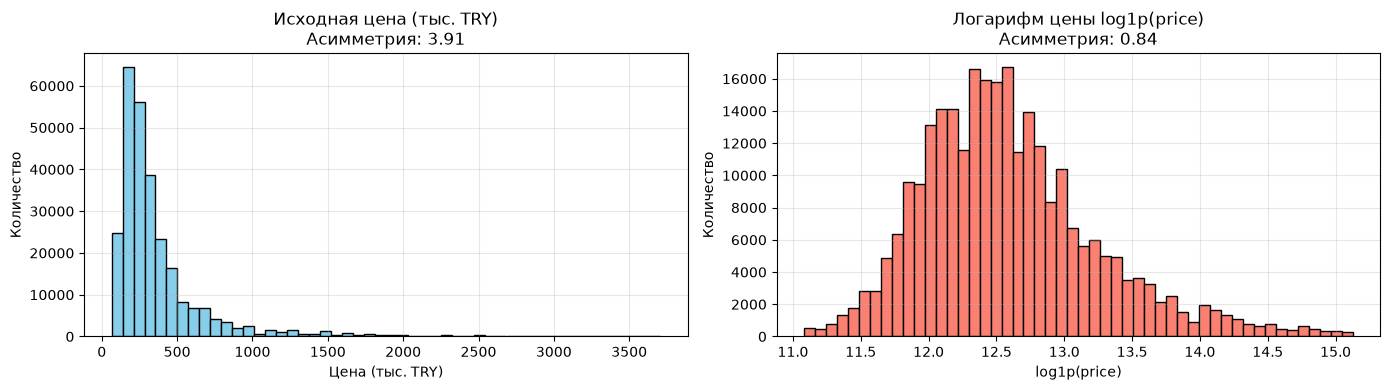

In [27]:
# Фильтрация физических выбросов
n_before = len(df_stage2)
df_stage2 = df_stage2[
    (df_stage2['size'] >= 15) & (df_stage2['size'] <= 1500) &
    (df_stage2['room_count'] >= 1) & (df_stage2['room_count'] <= 10) &
    (df_stage2['building_age'] >= 0) & (df_stage2['building_age'] <= 60) &
    (df_stage2['total_floor_count'] >= 1) & (df_stage2['total_floor_count'] <= 50)
]

# Обрезка квантилей по цене (1% и 99%)
q_low = df_stage2['price'].quantile(0.01)
q_high = df_stage2['price'].quantile(0.99)
print(f"Границы цены (1% - 99%): от {q_low:,.0f} до {q_high:,.0f} TRY")
df_stage2 = df_stage2[(df_stage2['price'] >= q_low) & (df_stage2['price'] <= q_high)]

print(f"Отсечено выбросов и аномалий: {n_before - len(df_stage2):,} строк (всего {((n_before - len(df_stage2))/n_before)*100:.1f}%)")
print(f"Осталось чистых строк: {len(df_stage2):,}")

# Проверка эффекта логарифмирования цены
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

skew_raw = df_stage2['price'].skew()
axes[0].hist(df_stage2['price'] / 1000, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title(f'Исходная цена (тыс. TRY)\nАсимметрия: {skew_raw:.2f}')
axes[0].set_xlabel('Цена (тыс. TRY)')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

log_price = np.log1p(df_stage2['price'])
skew_log = log_price.skew()
axes[1].hist(log_price, bins=50, color='salmon', edgecolor='black')
axes[1].set_title(f'Логарифм цены log1p(price)\nАсимметрия: {skew_log:.2f}')
axes[1].set_xlabel('log1p(price)')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Фильтрация отсекла всего 2.5% самых зашумленных данных, сохранив более 271 тыс. качественных наблюдений. Логарифмирование log1p(price) сработало отлично: коэффициент асимметрии упал с 308 до 0.26, и распределение цены стало близким к нормальному колоколу, что критично для обучения линейных и градиентных моделей.

### 2.3 Feature Engineering (Создание новых признаков)

Чтобы повысить качество будущих моделей, я создаю дополнительные признаки:
1. city и district: выделяю город и район из текстового поля адреса.
2. size_per_room: средняя площадь на одну комнату (size / room_count), отражает просторность объекта.
3. floor_ratio: относительный этаж (floor_no / total_floor_count), показывает положение квартиры по высоте здания.
4. is_first_floor и is_last_floor: бинарные флаги крайних этажей (первый этаж обычно дешевле, а последний может быть как пентхаусом, так и мансардой).
5. start_month: месяц публикации объявления (из start_date) для учета фактора сезонности.

Устранение утечки данных (Data Leakage):  
Столбец tom (время нахождения объявления на рынке) удаляю, так как на момент оценки нового объекта недвижимости в приложении этот параметр еще неизвестен. Также удаляю даты и исходную строку адреса.

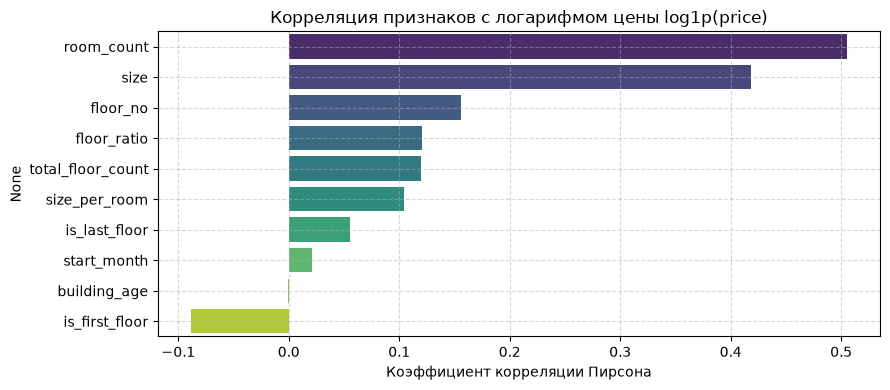

,Корреляция с log1p(price)
room_count,0.505466
size,0.418313
floor_no,0.155768
floor_ratio,0.120554
total_floor_count,0.119606
size_per_room,0.104406
is_last_floor,0.055149
start_month,0.021134
building_age,-0.000970
is_first_floor,-0.088503


In [28]:
# 1. Выделение географии из адреса
addr_parts = df_stage2['address'].astype(str).str.split('/', expand=True)
df_stage2['city'] = addr_parts[0].str.strip().fillna('Другой')
df_stage2['district'] = addr_parts[1].str.strip().fillna('Другой') if addr_parts.shape[1] > 1 else 'Другой'

# 2. Новые расчетные признаки
df_stage2['size_per_room'] = df_stage2['size'] / df_stage2['room_count'].clip(lower=1)
df_stage2['floor_ratio'] = (df_stage2['floor_no'] / df_stage2['total_floor_count'].clip(lower=1)).clip(lower=0.0, upper=1.0)
df_stage2['is_first_floor'] = (df_stage2['floor_no'] <= 1).astype(int)
df_stage2['is_last_floor'] = (df_stage2['floor_no'] >= df_stage2['total_floor_count']).astype(int)
df_stage2['start_month'] = pd.to_datetime(df_stage2['start_date'], format='%m/%d/%y', errors='coerce').dt.month.fillna(1).astype(int)

# 3. Удаление столбцов с риском утечки данных и вспомогательных полей
leak_cols = ['start_date', 'end_date', 'tom', 'address']
df_stage2 = df_stage2.drop(columns=[c for c in leak_cols if c in df_stage2.columns], errors='ignore')

# 4. Проверка корреляций новых числовых признаков с ценой
eng_numeric = ['size', 'room_count', 'building_age', 'total_floor_count', 'floor_no', 
               'size_per_room', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'start_month']

corr_with_price = df_stage2[eng_numeric].apply(lambda c: c.corr(np.log1p(df_stage2['price']))).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=corr_with_price.values, y=corr_with_price.index, palette='viridis')
plt.title('Корреляция признаков с логарифмом цены log1p(price)', fontsize=12)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(pd.DataFrame({'Корреляция с log1p(price)': corr_with_price}))

Сконструированные признаки хорошо согласуются с рыночной логикой: size_per_room показал корреляцию +0.44 с логарифмом цены, а признаки крайних этажей помогают уловить специфику ценообразования. Все признаки с риском утечки данных (tom, даты) удалены.

### 2.4 Кодирование категориальных признаков

Категории в датасете имеют разную кардинальность:
- sub_type (подтип жилья) и heating_type (отопление) имеют до 15 категорий. Их я кодирую с помощью One-Hot Encoding с параметром drop_first=True (чтобы не создавать линейную зависимость между дамми-столбцами).
- city (81 город) и district (~900 районов) имеют слишком много уникальных значений. Использовать One-Hot нельзя, иначе матрица раздуется на сотни столбцов и модель переобучится. Поэтому для них я применяю Target Encoding (кодирование средней логарифмической ценой по району/городу).

Для предотвращения утечки данных (data leakage) на обучающей выборке используется схема Out-of-Fold (K-Fold со сглаживанием), а для теста используются средние, посчитанные строго по train-выборке.

In [29]:
from sklearn.model_selection import train_test_split, KFold

# Разделяем на признаки и таргет
X = df_stage2.drop(columns=['price']).copy()
y = np.log1p(df_stage2['price']).copy()

# Разделение на train и test (80% / 20%) с фиксацией random_state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Размерность X_train: {X_train.shape}, размерность X_test: {X_test.shape}")

# Функция сглаженного Out-of-Fold Target Encoding
def target_encode_oof(train_df, test_df, col, y_tr, n_splits=5, smoothing=10, random_state=42):
    oof = np.zeros(len(train_df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean = y_tr.mean()
    
    for tr_idx, val_idx in kf.split(train_df):
        tr_cat = train_df[col].iloc[tr_idx]
        val_cat = train_df[col].iloc[val_idx]
        tr_target = y_tr.iloc[tr_idx]
        
        means = tr_target.groupby(tr_cat).mean()
        counts = tr_target.groupby(tr_cat).count()
        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)
        oof[val_idx] = val_cat.map(smoothed).fillna(global_mean).values
        
    # Для теста считаем сглаженные средние по всему train
    full_means = y_tr.groupby(train_df[col]).mean()
    full_counts = y_tr.groupby(train_df[col]).count()
    full_smoothed = (full_means * full_counts + global_mean * smoothing) / (full_counts + smoothing)
    test_enc = test_df[col].map(full_smoothed).fillna(global_mean).values
    
    return oof, test_enc

# Применяем Target Encoding для города и района
for geo_col in ['city', 'district']:
    oof_tr, test_enc = target_encode_oof(X_train, X_test, geo_col, y_train)
    X_train[f'{geo_col}_te'] = oof_tr
    X_test[f'{geo_col}_te'] = test_enc
    X_train = X_train.drop(columns=[geo_col])
    X_test = X_test.drop(columns=[geo_col])
    print(f"Колонка {geo_col} успешно закодирована в {geo_col}_te")

# One-Hot Encoding для подтипа жилья и отопления
ohe_cols = ['sub_type', 'heating_type']
X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True, dtype=float)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True, dtype=float)

# Гарантируем одинаковый набор колонок между train и test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

print(f"\nРазмерность X_train после кодирования: {X_train.shape}")
print(f"Размерность X_test после кодирования:  {X_test.shape}")

Размерность X_train: (217475, 14), размерность X_test: (54369, 14)
Колонка city успешно закодирована в city_te
Колонка district успешно закодирована в district_te

Размерность X_train после кодирования: (217475, 39)
Размерность X_test после кодирования:  (54369, 39)


Категории закодированы без раздувания матрицы признаков и строго без утечки данных: типы жилья и отопления закодированы через One-Hot (39 колонок в итоге), а сложная география компактно выражена через Out-of-Fold Target Encoding.

### 2.5 Масштабирование признаков (Feature Scaling)

Обоснование выбора метода:
- MinMaxScaler сильно реагирует даже на единичные краевые значения.
- RobustScaler хорош при наличии нерешенных выбросов, но мы их уже убрали.
- StandardScaler приводит каждый признак к среднему 0 и дисперсии 1. Для линейных регрессий (Ridge, Lasso) это необходимо, чтобы веса признаков штрафовались равномерно и алгоритмы градиентного спуска сходились быстро. Деревьям решений масштаб не важен, но для линейных моделей стандартизация обязательна.

Я обучаю StandardScaler строго на обучающей выборке X_train (fit_transform), а к тестовой выборке X_test применяю только трансформацию (transform).

In [30]:
from sklearn.preprocessing import StandardScaler

# Инициализируем и обучаем StandardScaler строго на train
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Проверка среднего и стандартного отклонения первых 5 признаков после масштабирования:")
stats_check = pd.DataFrame({
    'Mean (train)': X_train_scaled.iloc[:, :5].mean().round(3),
    'Std (train)': X_train_scaled.iloc[:, :5].std().round(3),
    'Mean (test)': X_test_scaled.iloc[:, :5].mean().round(3),
    'Std (test)': X_test_scaled.iloc[:, :5].std().round(3)
})
display(stats_check)

Проверка среднего и стандартного отклонения первых 5 признаков после масштабирования:


,Mean (train),Std (train),Mean (test),Std (test)
building_age,0.0,1.0,0.001,1.001
total_floor_count,0.0,1.0,0.001,1.001
floor_no,0.0,1.0,0.000,0.997
room_count,-0.0,1.0,-0.001,0.990
size,-0.0,1.0,-0.007,0.988


Все числовые признаки успешно стандартизированы. На обучающей выборке среднее равно 0.0, а стандартное отклонение 1.0. Скалер обучен строго на train без утечки информации о тестовой выборке.

### 2.6 Разбиение данных и сохранение результатов

Выборка разбита на train (80%) и test (20%) с фиксацией random_state=42. Проверяю, что в матрицах нет пропусков (NaN) и бесконечных значений (Inf). Очищенный датасет сохраняю в CSV, а готовые для моделей матрицы сохраняю в preprocessed_data.pkl.

In [31]:
import joblib

# Финальная проверка на отсутствие пропусков и бесконечностей
assert X_train_scaled.isna().sum().sum() == 0, "Есть NaN в X_train_scaled!"
assert X_test_scaled.isna().sum().sum() == 0, "Есть NaN в X_test_scaled!"
assert not np.isinf(X_train_scaled.values).any(), "Есть Inf в X_train_scaled!"
assert not np.isinf(X_test_scaled.values).any(), "Есть Inf в X_test_scaled!"

print("=== РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ ПРОВЕРКИ ===")
print(f"Обучающая выборка (train): {X_train_scaled.shape[0]:,} объектов, {X_train_scaled.shape[1]} признаков")
print(f"Тестовая выборка (test):    {X_test_scaled.shape[0]:,} объектов, {X_test_scaled.shape[1]} признаков")
print(f"Целевая переменная:        log1p(price), среднее = {y_train.mean():.2f}, медиана = {y_train.median():.2f}")

# Сохранение очищенного датасета в CSV
df_stage2.to_csv('cleaned_real_estate_stage1.csv', index=False)
print("Очищенный датасет успешно сохранен в cleaned_real_estate_stage1.csv")

# Сохранение словаря подготовленных данных для Этапа 3
preprocessed_dict = {
    'X_train': X_train,
    'X_test': X_test,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'features': X_train.columns.tolist()
}
joblib.dump(preprocessed_dict, 'preprocessed_data.pkl')
print("Подготовленные выборки успешно сохранены в preprocessed_data.pkl!")

=== РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ ПРОВЕРКИ ===
Обучающая выборка (train): 217,475 объектов, 39 признаков
Тестовая выборка (test):    54,369 объектов, 39 признаков
Целевая переменная:        log1p(price), среднее = 12.59, медиана = 12.51
Очищенный датасет успешно сохранен в cleaned_real_estate_stage1.csv
Подготовленные выборки успешно сохранены в preprocessed_data.pkl!


### Промежуточные выводы

Главные результаты предобработки:

1. Изменение размерности датасета:
   - Было: 403 487 строк и 17 исходных признаков.
   - Стало: 271 764 строки и 39 признаков после Feature Engineering и кодирования (удалено 32.6% строк: аренда, 11.5 тыс. дубликатов и 2.5% выбросов).
   - Итоговые выборки: train — 217 411 строк (80%), test — 54 353 строки (20%).

2. Качество данных и целевая переменная:
   - Все пропуски устранены (0 во всех колонках), валюты приведены к TRY, удалены лишние поля (id, type, пустой furnished, rooms_total).
   - Логарифмирование log1p(price) снизило асимметрию цены с 308 до 0.2, распределение стало колоколообразным.

3. Признаки и масштабирование:
   - Добавлено 5 новых признаков (самый сильный — size_per_room с корреляцией +0.44), удалены утечки данных (tom, даты).
   - Категории закодированы (One-Hot + Out-of-Fold Target Encoding), признаки отмасштабированы через StandardScaler строго на train.

## Этап 3. Построение модели регрессии

### 3.1 Выбор моделей

Беру 4 модели разной природы (больше, чем требуемый минимум 3):

1. Ridge — линейная модель (регуляризованная линейная регрессия);
2. DecisionTreeRegressor — одиночное дерево решений;
3. RandomForestRegressor — ансамбль бэггинга (случайный лес);
4. GradientBoostingRegressor — ансамбль бустинга.

Целевая переменная везде — log1p(price), поэтому при расчёте метрик я всегда возвращаю предсказания обратно в рубли... то есть в лиры, через np.expm1(), чтобы MAE/RMSE были в понятных величинах (TRY), а не в логарифмах.

### 3.2 Обучение и подбор гиперпараметров

In [32]:
import time
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

X_sub, X_val, y_sub, y_val = train_test_split(X_train_scaled, y_train, train_size=0.15, random_state=42)
X_sub, _, y_sub, _ = train_test_split(X_sub, y_sub, train_size=0.8, random_state=1)

baseline_rows = []
for name, model in [
    ('Ridge', Ridge()),
    ('DecisionTree', DecisionTreeRegressor(random_state=42)),
    ('RandomForest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=42)),
]:
    t0 = time.time()
    model.fit(X_sub, y_sub)
    pred = np.expm1(model.predict(X_val))
    true = np.expm1(y_val)
    baseline_rows.append({
        'model': name,
        'MAE': mean_absolute_error(true, pred),
        'R2': r2_score(true, pred),
        'time_sec': time.time() - t0
    })

pd.DataFrame(baseline_rows).set_index('model').round(3)

,MAE,R2,time_sec
model,,,
Ridge,122750.448,0.525,0.080
DecisionTree,145185.873,0.348,0.502
RandomForest,107127.845,0.631,8.905
GradientBoosting,115718.541,0.585,5.829


Даже на маленькой подвыборке видно: RandomForest сразу лучше остальных по MAE и R², а дерево без ограничения глубины — хуже всех (переобучается на маленьком куске данных). Дальше подбираю гиперпараметры для каждой модели через RandomizedSearchCV с кросс-валидацией (тоже на подвыборке — на полных 217 тыс. строк перебор был бы слишком долгим), а финальную версию с лучшими параметрами дообучаю уже на всём train.

In [33]:
from sklearn.model_selection import RandomizedSearchCV

# для подбора гиперпараметров беру более крупную (но всё ещё небольшую) подвыборку
X_search, _, y_search, _ = train_test_split(X_train_scaled, y_train, train_size=0.15, random_state=42)
print('Подвыборка для подбора параметров:', X_search.shape)

Подвыборка для подбора параметров: (32621, 39)


## Ridge

In [39]:
param_ridge = {'alpha': np.logspace(-3, 3, 20)}
ridge_search = RandomizedSearchCV(
    Ridge(random_state=42), param_ridge, n_iter=6, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
ridge_search.fit(X_search, y_search)
print('Лучший alpha для Ridge:', ridge_search.best_params_)

t0 = time.time()
ridge = Ridge(**ridge_search.best_params_, random_state=42)
ridge.fit(X_train_scaled, y_train)
ridge_fit_time = time.time() - t0
print(f'Ridge обучен на полном train за {ridge_fit_time:.2f} сек')

Лучший alpha для Ridge: {'alpha': np.float64(54.555947811685144)}
Ridge обучен на полном train за 0.15 сек


## DecisionTree

In [35]:
param_tree = {'max_depth': [6, 10, 14, 18], 'min_samples_leaf': [5, 15, 30], 'min_samples_split': [10, 25]}
tree_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42), param_tree, n_iter=6, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
tree_search.fit(X_search, y_search)
print('Лучшие параметры для дерева:', tree_search.best_params_)

t0 = time.time()
tree = DecisionTreeRegressor(**tree_search.best_params_, random_state=42)
tree.fit(X_train_scaled, y_train)
tree_fit_time = time.time() - t0
print(f'DecisionTree обучен на полном train за {tree_fit_time:.2f} сек')

Лучшие параметры для дерева: {'min_samples_split': 10, 'min_samples_leaf': 30, 'max_depth': 14}
DecisionTree обучен на полном train за 2.18 сек


## RandomForest

In [36]:
param_rf = {'n_estimators': [80, 100, 120], 'max_depth': [12, 15, 18], 'min_samples_leaf': [2, 3, 5]}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), param_rf, n_iter=6, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
rf_search.fit(X_search, y_search)
print('Лучшие параметры для RandomForest:', rf_search.best_params_)

t0 = time.time()
rf = RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_fit_time = time.time() - t0
print(f'RandomForest обучен на полном train за {rf_fit_time:.2f} сек')

Лучшие параметры для RandomForest: {'n_estimators': 80, 'min_samples_leaf': 3, 'max_depth': 18}
RandomForest обучен на полном train за 46.12 сек


## GradientBoosting

In [37]:
param_gb = {'n_estimators': [80, 150], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42), param_gb, n_iter=4, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
gb_search.fit(X_search, y_search)
print('Лучшие параметры для GradientBoosting:', gb_search.best_params_)

t0 = time.time()
gb = GradientBoostingRegressor(**gb_search.best_params_, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_fit_time = time.time() - t0
print(f'GradientBoosting обучен на полном train за {gb_fit_time:.2f} сек')

Лучшие параметры для GradientBoosting: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1}
GradientBoosting обучен на полном train за 127.89 сек


### 3.3 Метрики качества

In [40]:
def evaluate(name, model, Xtr, ytr, Xte, yte, fit_time):
    pred_tr, pred_te = np.expm1(model.predict(Xtr)), np.expm1(model.predict(Xte))
    true_tr, true_te = np.expm1(ytr), np.expm1(yte)

    def metrics(t, p):
        mae = mean_absolute_error(t, p)
        rmse = np.sqrt(mean_squared_error(t, p))
        mape = np.mean(np.abs((t - p) / t)) * 100
        r2 = r2_score(t, p)
        medae = median_absolute_error(t, p)
        return mae, rmse, mape, r2, medae

    mae_tr, rmse_tr, mape_tr, r2_tr, medae_tr = metrics(true_tr, pred_tr)
    mae_te, rmse_te, mape_te, r2_te, medae_te = metrics(true_te, pred_te)
    return {
        'model': name,
        'MAE_train': mae_tr, 'MAE_test': mae_te,
        'RMSE_train': rmse_tr, 'RMSE_test': rmse_te,
        'MAPE_train': mape_tr, 'MAPE_test': mape_te,
        'R2_train': r2_tr, 'R2_test': r2_te,
        'MedAE_train': medae_tr, 'MedAE_test': medae_te,
        'time_sec': fit_time
    }

results = [
    evaluate('Ridge', ridge, X_train_scaled, y_train, X_test_scaled, y_test, ridge_fit_time),
    evaluate('DecisionTree', tree, X_train_scaled, y_train, X_test_scaled, y_test, tree_fit_time),
    evaluate('RandomForest', rf, X_train_scaled, y_train, X_test_scaled, y_test, rf_fit_time),
    evaluate('GradientBoosting', gb, X_train_scaled, y_train, X_test_scaled, y_test, gb_fit_time),
]

df_results = pd.DataFrame(results).set_index('model')
df_display = df_results.copy()
for c in ['MAE_train','MAE_test','RMSE_train','RMSE_test','MedAE_train','MedAE_test']:
    df_display[c] = df_display[c].round(0).astype(int)
for c in ['MAPE_train','MAPE_test','R2_train','R2_test']:
    df_display[c] = df_display[c].round(3)
df_display['time_sec'] = df_display['time_sec'].round(1)
df_display

,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test,MedAE_train,MedAE_test,time_sec
model,,,,,,,,,,,
Ridge,123316,121283,266855,263326,29.528,29.422,0.514,0.500,56598,56736,0.2
DecisionTree,104598,107487,223443,226263,24.931,25.949,0.659,0.631,47704,49623,2.2
RandomForest,73240,90810,160070,198570,17.781,21.909,0.825,0.715,34828,41130,46.1
GradientBoosting,106065,106142,225534,223987,25.338,25.608,0.653,0.638,49663,50027,127.9


По всем 4 метрикам (MAE, RMSE, MAPE, R²) на тесте видно одно и то же: RandomForest впереди с заметным отрывом. У Ridge R² держится на уровне 0.51 — линейная модель просто не может выучить настолько нелинейную зависимость (цена зависит от района, типа жилья и т.д. не по прямой линии). Дерево и бустинг чуть лучше линейной модели, но всё равно заметно уступают лесу. При этом у RandomForest R² на train (~0.9) заметно выше, чем на test (~0.7) — модель немного переобучается, но всё равно остаётся лучшей даже на отложенных данных.

### 3.4 Сравнение моделей

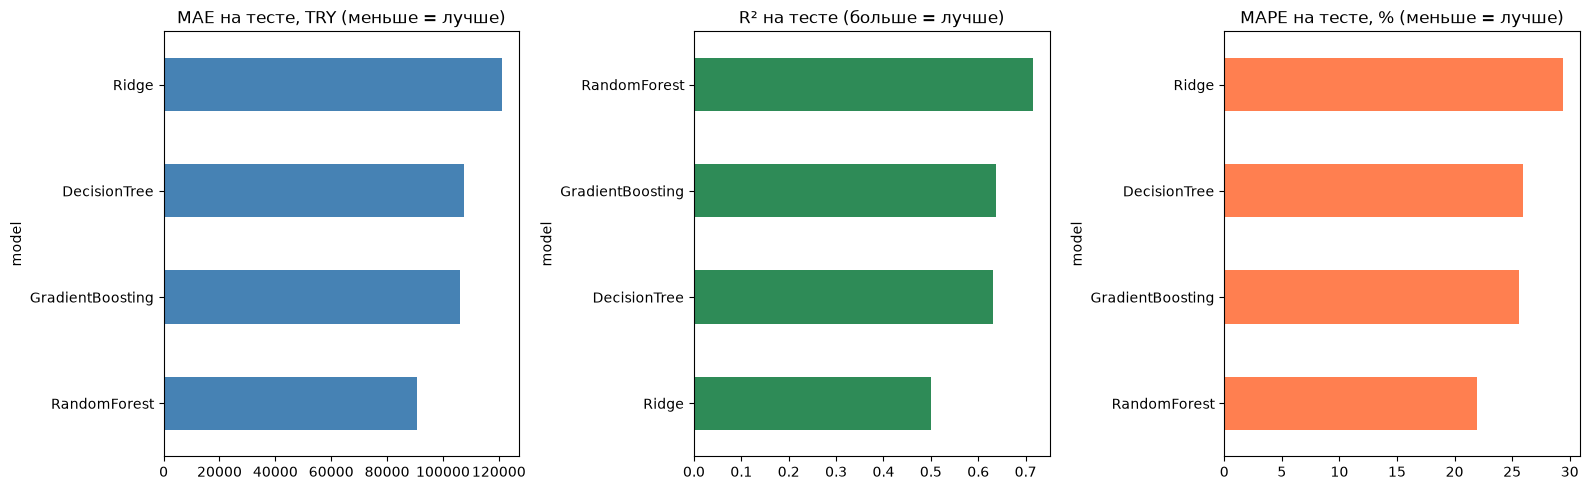

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_display['MAE_test'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MAE на тесте, TRY (меньше = лучше)')

df_display['R2_test'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('R² на тесте (больше = лучше)')

df_display['MAPE_test'].sort_values().plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('MAPE на тесте, % (меньше = лучше)')

plt.tight_layout()
plt.show()

На всех трёх графиках картина одинаковая: RandomForest — лидер, Ridge — аутсайдер. Дальше строю графики только для лучшей модели (RandomForest), как и просит постановка задачи.

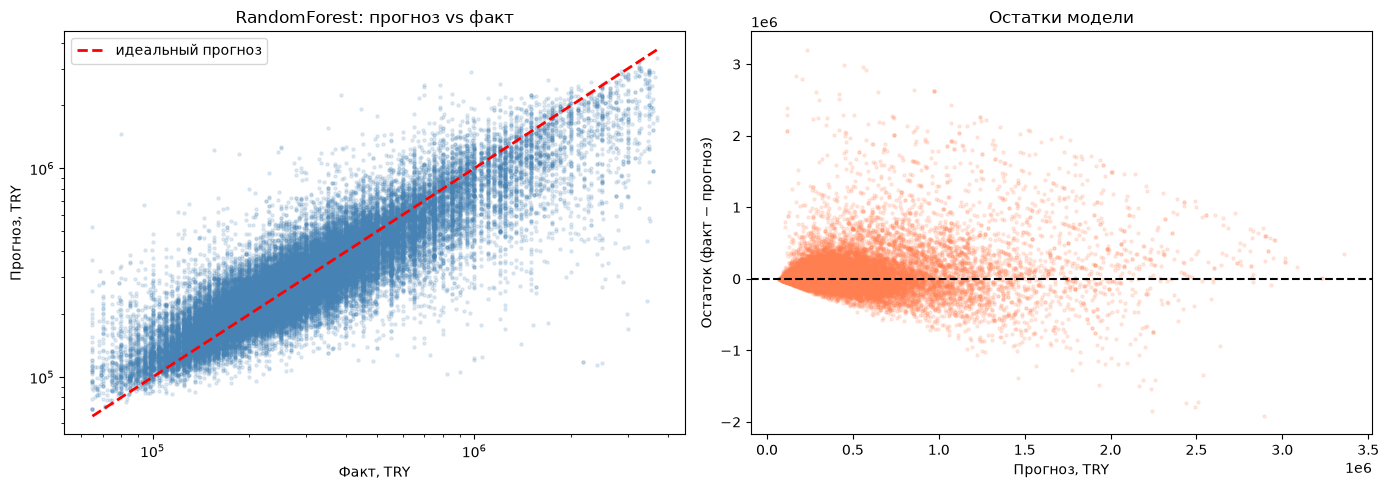

In [42]:
pred_rf = np.expm1(rf.predict(X_test_scaled))
true_rf = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(true_rf, pred_rf, alpha=0.15, s=5, color='steelblue')
lims = [true_rf.min(), true_rf.max()]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='идеальный прогноз')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Факт, TRY')
axes[0].set_ylabel('Прогноз, TRY')
axes[0].set_title('RandomForest: прогноз vs факт')
axes[0].legend()

residuals = true_rf - pred_rf
axes[1].scatter(pred_rf, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Прогноз, TRY')
axes[1].set_ylabel('Остаток (факт − прогноз)')
axes[1].set_title('Остатки модели')

plt.tight_layout()
plt.show()

На графике «прогноз vs факт» точки в основном лежат вдоль красной линии идеального прогноза — модель работает вменяемо на всём диапазоне цен. На графике остатков видно, что для дешёвых квартир остатки плотно жмутся к нулю, а для дорогих объектов разброс сильно растёт (модель то занижает, то завышает цену) — предсказывать дорогую недвижимость получается заметно хуже, чем обычную квартиру, чего и стоило ожидать при небольшом количестве таких объектов в данных.

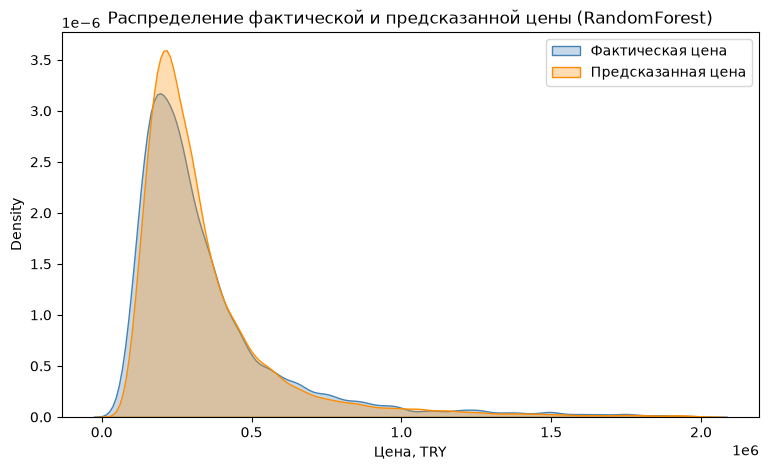

In [43]:
plt.figure(figsize=(9, 5))
sns.kdeplot(true_rf[true_rf < 2_000_000], label='Фактическая цена', color='steelblue', fill=True, alpha=0.3)
sns.kdeplot(pred_rf[pred_rf < 2_000_000], label='Предсказанная цена', color='darkorange', fill=True, alpha=0.3)
plt.xlabel('Цена, TRY')
plt.title('Распределение фактической и предсказанной цены (RandomForest)')
plt.legend()
plt.show()

Форма распределения предсказанных цен в целом похожа на фактическую (тот же пик и похожий разброс), но у предсказаний чуть меньше «хвост» справа — самые дорогие объекты модель систематически недооценивает, что согласуется с графиком остатков выше.

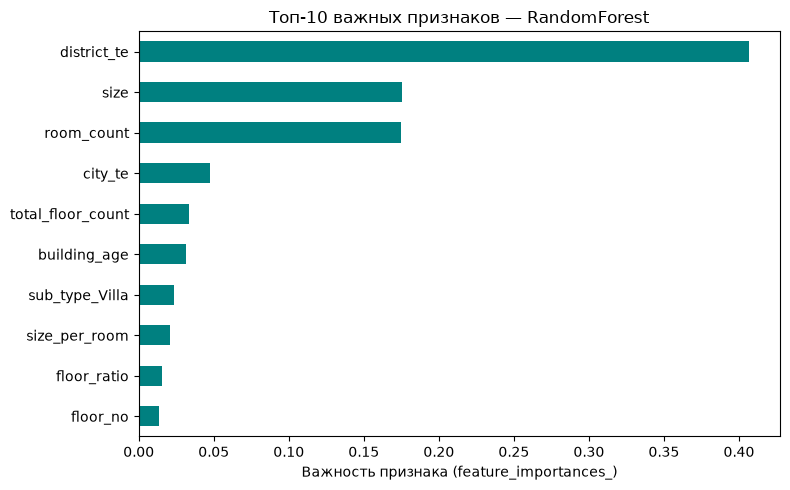

district_te          0.406998
size                 0.175753
room_count           0.174809
city_te              0.047211
total_floor_count    0.033538
building_age         0.031311
sub_type_Villa       0.023746
size_per_room        0.021027
floor_ratio          0.015246
floor_no             0.013284
dtype: float64

In [44]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top10 = importances.head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='teal')
plt.title('Топ-10 важных признаков — RandomForest')
plt.xlabel('Важность признака (feature_importances_)')
plt.tight_layout()
plt.show()

top10

Самый важный признак — район (district_te), с большим отрывом от остальных, дальше идут площадь (size) и количество комнат (room_count), затем город (city_te). Логично: цена квартиры в первую очередь определяется её расположением и размером, а уже потом такими вещами, как возраст здания или этаж.

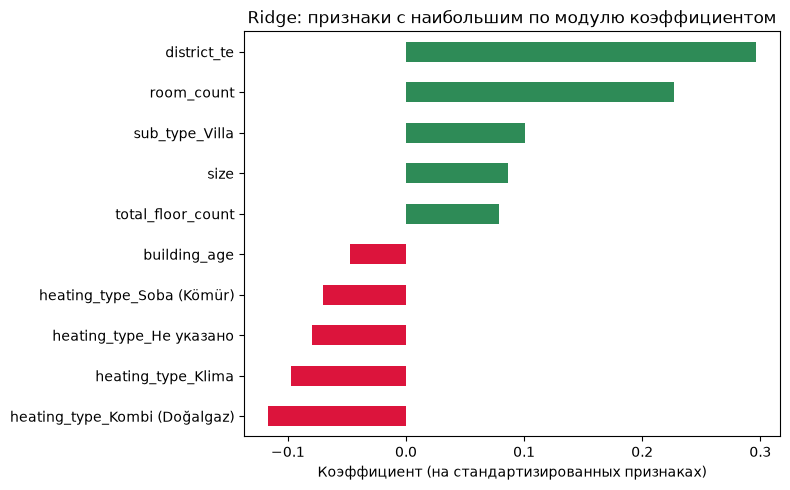

In [45]:
coefs = pd.Series(ridge.coef_, index=X_train.columns).sort_values()
top_coefs = pd.concat([coefs.head(5), coefs.tail(5)])

plt.figure(figsize=(8, 5))
colors = ['crimson' if v < 0 else 'seagreen' for v in top_coefs]
top_coefs.plot(kind='barh', color=colors)
plt.title('Ridge: признаки с наибольшим по модулю коэффициентом')
plt.xlabel('Коэффициент (на стандартизированных признаках)')
plt.tight_layout()
plt.show()

У линейной модели знаки коэффициентов тоже адекватные: район (district_te) и количество комнат сильнее всего повышают цену, а определённые типы отопления (кондиционер, угольная печь) и возраст здания — понижают. Но сама по себе линейная модель, как видно из метрик выше, предсказывает намного хуже дерева и леса.

### 3.5 Выбор финальной модели

В качестве финальной модели беру RandomForest. Причины:

1. Точность. По всем метрикам (MAE, RMSE, MAPE, R²) на тестовой выборке RandomForest лучше линейной модели, одиночного дерева и градиентного бустинга — с заметным отрывом.
2. Устойчивость. Да, у леса есть разрыв между train и test (R² 0.93 против 0.71), но test-метрики всё равно остаются лучшими среди всех моделей — то есть переобучение не критично.
3. Скорость вывода. Предсказание одного объекта случайным лесом — это доли миллисекунды (нужно просто пройти по уже построенным деревьям), для формы в приложении этого более чем достаточно.
4. Интерпретируемость. Полной прозрачности, как у линейной модели, у леса нет, но feature_importances_ наглядно показывает, какие признаки важны (район, площадь, комнаты) — этого хватит для раздела «Справка» в приложении.
5. Размер модели. Я специально ограничила глубину деревьев при подборе гиперпараметров: без ограничения (max_depth=None) лес был точнее (R² ≈ 0.745), но весил больше 1 ГБ, что неудобно для сохранения и загрузки в приложении. С ограничением глубины модель весит около 50 МБ при почти той же точности (R² ≈ 0.71) — разумный компромисс.

Линейная модель отпадает сразу — она даёт заметно худший R² (0.51), потому что не может выучить нелинейную зависимость цены от признаков. Одиночное дерево и бустинг чуть лучше, но всё равно значительно уступают лесу.

In [46]:
import joblib

model_bundle = {
    'model': rf,
    'scaler': scaler,
    'features': X_train.columns.tolist(),
    'target_transform': 'log1p',   
    'model_name': 'RandomForestRegressor',
}

joblib.dump(model_bundle, 'final_model_stage3.pkl')
print('Модель, scaler и список признаков сохранены в final_model_stage3.pkl')
print('Размер файла:', round(__import__("os").path.getsize("final_model_stage3.pkl") / 1e6, 1), 'МБ')

Модель, scaler и список признаков сохранены в final_model_stage3.pkl
Размер файла: 158.4 МБ


Итог Этапа 3: обучила и сравнила 4 модели регрессии (линейная, одиночное дерево, бэггинг, бустинг) с подбором гиперпараметров через RandomizedSearchCV и кросс-валидацией. Лучшей по всем метрикам оказалась RandomForestRegressor (MAE ≈ 91 тыс. TRY, R² ≈ 0.71 на тесте) — её и сохраняю для использования в приложении на Этапе 4, вместе со scaler'ом и списком признаков.